In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("../src/data/df_2025_limpio.csv")

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6861 entries, 0 to 6860
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            6861 non-null   str    
 1   host_id                         6861 non-null   int64  
 2   host_name                       6861 non-null   str    
 3   neighbourhood                   6861 non-null   str    
 4   room_type                       6861 non-null   str    
 5   price                           6861 non-null   float64
 6   minimum_nights                  6861 non-null   int64  
 7   number_of_reviews               6861 non-null   int64  
 8   last_review                     6861 non-null   str    
 9   reviews_per_month               6861 non-null   float64
 10  calculated_host_listings_count  6861 non-null   int64  
 11  availability_365                6861 non-null   int64  
 12  number_of_reviews_ltm           6861 non-null

In [ ]:
# HIPÓTESIS 1
# Los alojamientos ubicados en el Centro tienen precios más altos que los alojamientos del resto de barrios.

# JUSTIFICACIÓN DE LA HIPÓTESIS
# El Centro concentra la mayor parte de la oferta (6389 alojamientos), es la zona más turística y suele tener mayor demanda, 
# lo que razonablemente podría elevar los precios.

# PLAN DE ACCIÓN
# Si la hipótesis se confirma:
# - Analizaremos qué factores dentro del Centro explican ese precio más alto:
#       - tipo de habitación (room_type)
#       - número de reseñas (number_of_reviews)
#       - disponibilidad anual (availability_365)
#       - actividad mensual (reviews_per_month)

# Compararemos el Centro con los dos siguientes barrios más relevantes (Este y Carretera de Cádiz) para ver si la diferencia es estructural 
# o puntual.

# Si la hipótesis no se confirma:
# - Analizaremos cuales son los factores que más influyen en el precio medio:
#       - Tipo de habitación (room_type)
#       - Número de reseñas (number_of_reviews)
#       - Actividad mensual (reviews_per_month)
#       - Disponibilidad anual (availability_365)  
#       - Mínimo de noches (minimum_nights)
#       - Número de alojamientos gestionados por el host (calculated_host_listings_count)  

In [3]:
df.groupby("neighbourhood")["price"].mean().sort_values(ascending=False)


neighbourhood
Campanillas             2989.210526
Churriana                594.290909
Puerto de la Torre       444.931034
Este                     310.222061
Teatinos-Universidad     284.127660
Cruz De Humilladero      255.663265
Carretera de Cadiz       251.097598
Centro                   157.234670
Palma-Palmilla           141.650407
Ciudad Jardin            113.134615
Bailen-Miraflores         73.589862
Name: price, dtype: float64

In [ ]:
# Reformular la hipótesis
# Analizar si Campanillas tiene algun outlier que eleven la media de forma desproporcional

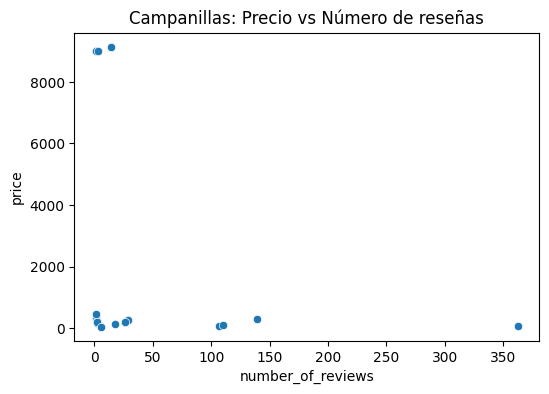

In [4]:
df_campanillas = df[df["neighbourhood"]=="Campanillas"]

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df[df["neighbourhood"]=="Campanillas"],
    x="number_of_reviews",
    y="price"
)
plt.title("Campanillas: Precio vs Número de reseñas")
plt.show()


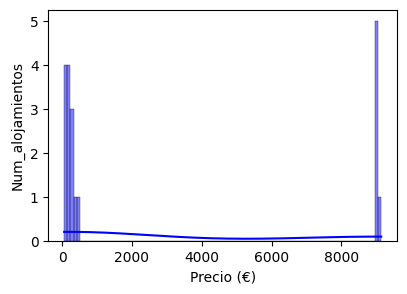

In [31]:
# HISTOGRAMA Y KDE

fig, axs = plt.subplots(1,1,figsize= (4.5,3))

sns.histplot(
    df_campanillas["price"],
    kde=True,
    color="b",
    bins=100,
    ax = axs
)
axs.set_xlabel("Precio (€)")
axs.set_ylabel("Num_alojamientos");

In [ ]:
# El análisis del precio frente al número de reseñas en Campanillas muestra que los valores extremadamente altos corresponden a 
# alojamientos con muy poca actividad (casi sin reseñas). Estos puntos actúan como outliers y distorsionan la media del barrio. 
# La mayoría de alojamientos tienen precios moderados, por lo que el precio medio elevado de Campanillas no refleja una tendencia real, 
# sino la presencia de unos pocos alojamientos atípicos.

In [5]:
df_campanillas[["price", "number_of_reviews", "availability_365"]].describe()


,price,number_of_reviews,availability_365
count,19.000000,19.000000,19.000000
mean,2989.210526,43.578947,287.210526
std,4213.307682,88.398916,95.501355
min,56.000000,1.000000,57.000000
25%,157.500000,1.500000,225.500000
50%,259.000000,3.000000,354.000000
75%,9000.000000,27.500000,363.000000
max,9143.000000,363.000000,364.000000


In [ ]:
# De esta tabla podemos deducir que solo hay 19 alojamientos en Campanillas, lo que representa un 0.27 % de los alojamientos disponibles 
# en Málaga, el 50% de esos 19 alojamientos están a un precio de 259 €. Vamos a ver cuales son los alojamientos que están por encima del Q3

In [6]:
# vamos a calcular cuales son esos outliers
df_campanillas["price"].quantile(0.75)


np.float64(9000.0)

In [36]:
outliers_Q2 = df_campanillas[df_campanillas["price"] >df_campanillas["price"].quantile(0.5)]
outliers_Q2


,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
1835,"Málaga, CASUEÑA Casa tropical en Málaga ciudad.",197290816,Alicia,Campanillas,Entire home/apt,294.0,3,139,2025-09-13,2.22,1,201,28,VTAR/MA/03155
1882,Amplia casa rural con magnifico jardín.,368251395,Carmen,Campanillas,Entire home/apt,259.0,2,29,2025-08-20,0.50,1,180,12,CR/MA/02405
2282,Casa Rural Cupiana Málaga by Ruralidays,392227252,Ruralidays,Campanillas,Entire home/apt,345.0,1,1,2025-06-30,0.32,10,256,1,CR/MA/01798
3786,Maravilloso chalet independiente en Málaga cap...,45221462,Inmaculada,Campanillas,Entire home/apt,212.0,4,26,2025-09-22,1.65,1,356,17,VFT/MA/63115
4027,Casa Rural Los Almendros,212687015,Raquel,Campanillas,Entire home/apt,250.0,1,2,2025-08-24,0.14,2,357,1,2023999010410228
6292,Lujo y privacidad con piscina y jardines,688273534,Moises,Campanillas,Entire home/apt,465.0,2,1,2025-08-03,0.51,1,177,1,VTAR/MA/04871


In [12]:
df_campanillas[df_campanillas["host_name"] == "Michael"]

,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
4317,Limón Lunero,544263779,Michael,Campanillas,Entire home/apt,9143.0,1,14,2025-08-18,0.69,3,354,10,VFT/MA/62520
6336,La Cochera,686781509,Michael,Campanillas,Entire home/apt,9000.0,1,2,2025-08-29,1.02,8,364,2,ESHFTU00002900100001917200100000000000000CR/MA...
6428,La Yegueriza,686781509,Michael,Campanillas,Entire home/apt,9000.0,1,1,2025-07-15,0.38,8,364,1,ESHFTU00002900100001917200300000000000000CR/MA...
6429,El Granero,686781509,Michael,Campanillas,Entire home/apt,9000.0,1,1,2025-08-25,0.81,8,364,1,ESHFTU00002900100001917200600000000000000CR/MA...
6430,El Pajar,686781509,Michael,Campanillas,Entire home/apt,9000.0,1,1,2025-08-04,0.52,8,364,1,ESHFTU00002900100001917200200000000000000CR/MA...
6602,La Mihilla,686781509,Michael,Campanillas,Entire home/apt,9000.0,1,3,2025-09-06,1.70,8,362,3,VFT/MA/62520


In [ ]:
# Este host_name: "Michael" tiene alojamientos completos muy por encima de la media situados en "Campanillas", vamos a ver si este tiene 
# mas alojamientos en Málaga y que precios tienen esos alojamientos 

In [26]:
df[df["host_name"] == "Michael"]

,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
5,Apartment historical centre Malaga,2055304,Michael,Centro,Entire home/apt,78.0,4,52,2025-09-03,0.33,1,276,15,CTC-2023053184
1319,400 Julia - Centro Historico,170550376,Michael,Centro,Entire home/apt,117.0,1,13,2025-08-03,0.17,1,105,5,ESFCTU0000290200001250890000000000000000VUT/MA...
1959,Maravilloso Ático en Pleno Centro,205496849,Michael,Centro,Entire home/apt,9429.0,1,10,2025-06-05,0.19,1,363,2,ESFCTU0000290200002090240000000000000000VUT/MA...
2052,Finca Llano de Fe,285670200,Michael,Puerto de la Torre,Entire home/apt,9000.0,1,10,2025-06-15,0.20,2,364,2,ESFCTU00002902400005222200000000000000000CR/MA...
2132,Villa La bicicleta azul,187050772,Michael,Este,Entire home/apt,336.0,1,11,2025-06-07,0.22,1,363,5,ESFCTU0000290200000986350000000000000000VFT/MA...
2289,New House in Malaga Nature,184599578,Michael,Este,Entire home/apt,10000.0,1,3,2025-09-05,0.08,8,364,2,ESHFTU000029020000331268002000000000000VTAR/MA...
2293,Sailor House Slow Life in Nature,184599578,Michael,Este,Entire home/apt,10000.0,1,5,2025-08-04,0.11,8,364,1,ESHFTU000029020000331268001000000000000VTAR/MA...
2341,Finca Arroyo de las Adelfas,184599578,Michael,Palma-Palmilla,Entire home/apt,718.0,1,11,2025-06-08,0.38,8,359,3,CTC-2018109041
2575,Beach apartment in Malaga,431977102,Michael,Este,Entire home/apt,9000.0,1,6,2025-04-19,0.14,2,363,2,ESFCTU0000290200006370250000000000000000VUT/MA...
2704,Apartamento Residencial Limonar,432581747,Michael,Este,Entire home/apt,8000.0,1,5,2025-08-24,0.17,3,365,1,VFT/MA/546565


In [14]:
df["host_name"].value_counts()

host_name
Jose                   194
Remy                   137
Antonio                132
Living4Malaga          107
Ana                     94
                      ... 
Claudia De África        1
Yanina                   1
Wilder                   1
Abrahan                  1
Alejandra Margarita      1
Name: count, Length: 1368, dtype: int64

In [16]:
df[df["host_name"] == "Michael"].value_counts().sum()

np.int64(59)

In [ ]:
# vamos a crear un nuevo DF sin host_name "Michael", ya que este tiene precios desproporcionados y vamos a comprobar si quitando este cuanto
# seria la media de precios según el barrio
df_1 = df[df["host_name"] != "Michael"]


In [21]:
print("MEDIA SIN MICHAEL")
print(df_1.groupby("neighbourhood")["price"].mean().sort_values(ascending=False))
print("\n--------------------------------------\n")
print("MEDIA CON MICHAEL")
print(df.groupby("neighbourhood")["price"].mean().sort_values(ascending=False))


MEDIA SIN MICHAEL
neighbourhood
Churriana               443.259259
Campanillas             204.000000
Este                    194.168639
Carretera de Cadiz      141.685410
Puerto de la Torre      139.392857
Palma-Palmilla          136.926230
Centro                  128.663838
Cruz De Humilladero     127.766551
Ciudad Jardin           113.134615
Teatinos-Universidad     82.217391
Bailen-Miraflores        73.412037
Name: price, dtype: float64

--------------------------------------

MEDIA CON MICHAEL
neighbourhood
Campanillas             2989.210526
Churriana                594.290909
Puerto de la Torre       444.931034
Este                     310.222061
Teatinos-Universidad     284.127660
Cruz De Humilladero      255.663265
Carretera de Cadiz       251.097598
Centro                   157.234670
Palma-Palmilla           141.650407
Ciudad Jardin            113.134615
Bailen-Miraflores         73.589862
Name: price, dtype: float64


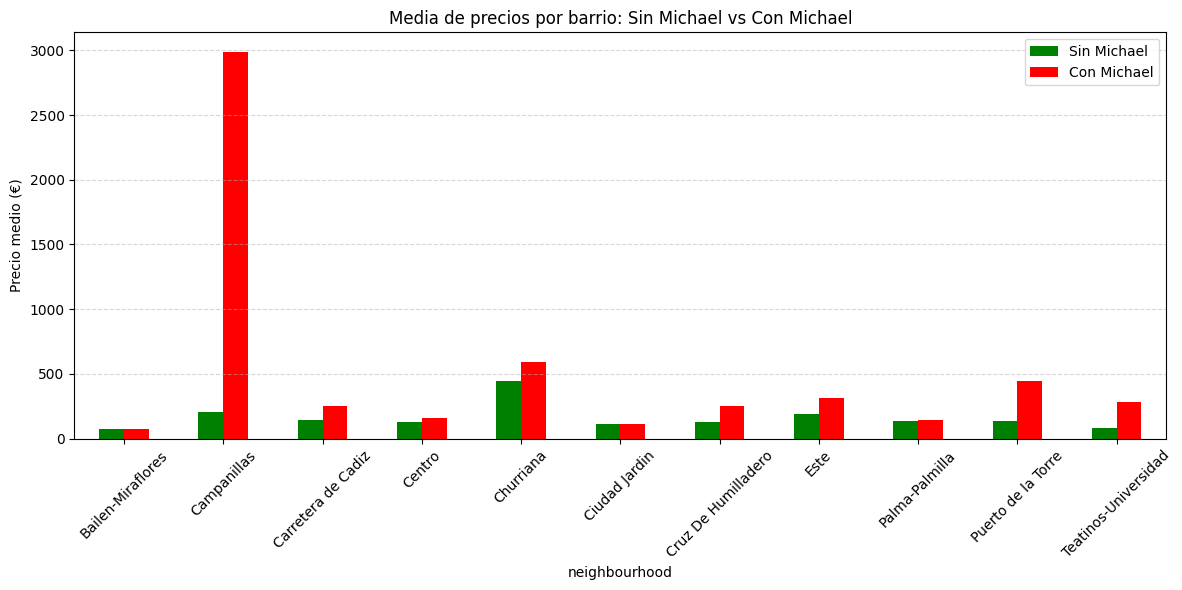

In [23]:
media_sin = df_1.groupby("neighbourhood")["price"].mean()
media_con = df.groupby("neighbourhood")["price"].mean()

comparativa = pd.DataFrame({
    "Sin Michael": media_sin,
    "Con Michael": media_con
})

# Plot
comparativa.plot(kind="bar", figsize=(12,6), color=["g", "r"])
plt.title("Media de precios por barrio: Sin Michael vs Con Michael")
plt.ylabel("Precio medio (€)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# La comparación entre los precios medios por barrio con el dataset completo (df) y el dataset sin el host Michael (df_1) revela que este 
# anfitrión actúa como un outlier estructural. Michael concentra un número muy elevado de alojamientos y utiliza precios anormalmente altos, 
# lo que provoca que la media de varios barrios aumente de manera artificial. El caso más evidente es Campanillas, donde la media pasa de 
# valores razonables a cifras superiores a 2.900 €, completamente alejadas del comportamiento general del mercado.

In [29]:
# volvemos al inicio de la hipótesis 1 calculando el precio medio por barrio (sin Michael)
df_1.groupby("neighbourhood")["price"].mean().sort_values(ascending=False)

neighbourhood
Churriana               443.259259
Campanillas             204.000000
Este                    194.168639
Carretera de Cadiz      141.685410
Puerto de la Torre      139.392857
Palma-Palmilla          136.926230
Centro                  128.663838
Cruz De Humilladero     127.766551
Ciudad Jardin           113.134615
Teatinos-Universidad     82.217391
Bailen-Miraflores        73.412037
Name: price, dtype: float64

In [ ]:
# vamos a ver ahora que pasa en Churriana.

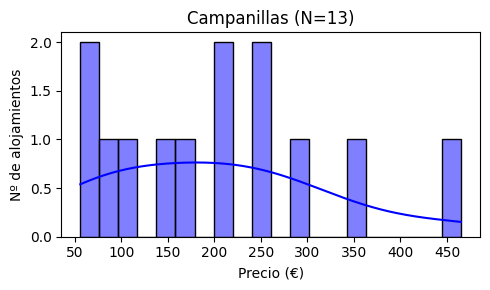

In [ ]:
# HISTOGRAMA Y KDE: comprobamos de nuevo el histograma de campanillas sin Michael

df_campanillas = df_1[df_1["neighbourhood"]=="Campanillas"]

fig, ax = plt.subplots(figsize=(5,3))

sns.histplot(
    df_campanillas["price"],
    kde=True,          # quitamos la curva
    bins=20,            # menos bins, más legible
    color="b",
    ax=ax
)

ax.set_xlabel("Precio (€)")
ax.set_ylabel("Nº de alojamientos")
ax.set_title(f"Campanillas (N={len(df_campanillas)})")

plt.tight_layout()
plt.show()

In [ ]:
# Este gráfico nos muestra que no tenemos valores extremos en campanilla para un total de 13 alojamientos, y tenemos una curva kde estable

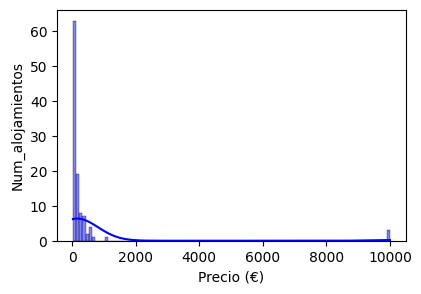

In [35]:
df_churriana = df_1[df_1["neighbourhood"]=="Churriana"]

fig, axs = plt.subplots(1,1,figsize= (4.5,3))

sns.histplot(
    df_churriana["price"],
    kde=True,
    color="b",
    bins=100,
    ax = axs
)
axs.set_xlabel("Precio (€)")
axs.set_ylabel("Num_alojamientos");

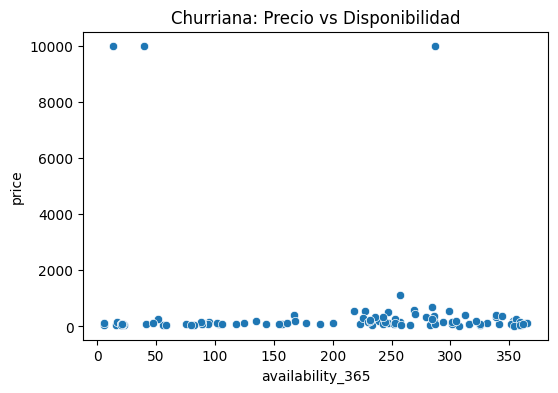

In [40]:
df_churriana = df_1[df_1["neighbourhood"]=="Churriana"]

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_churriana,
    x="availability_365",
    y="price"
)
plt.title("Churriana: Precio vs Disponibilidad")
plt.show()

In [41]:
# En Churriana tambien podemos detectar que tiene algunos outliers, en especial 3 bastantes elevados. Vamos a ver cuales son esos valores que 
# están por encima del Q3
outliers_Q3 = df_churriana[df_churriana["price"] >df_churriana["price"].quantile(0.75)]
outliers_Q3

,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
300,5 bd+5 bth+heated pool+sea view+hot tub+Privacy,64560946,Elena,Churriana,Entire home/apt,415.0,7,94,2025-09-06,0.83,1,167,8,CR/MA/00897
587,OHANA 1 Luxury Villa heated pool & cover wet bar,1739208,Estefania,Churriana,Entire home/apt,558.0,3,79,2025-08-16,0.79,2,299,4,CTC-2019023656
1152,Villa Guadalmar 34,101710304,Manuel,Churriana,Entire home/apt,532.0,3,82,2025-09-27,1.17,1,227,27,VFT/MA/29481
1321,"Ohana 2 Luxury Villa • Sunshine, Pool & Cinema",1739208,Estefania,Churriana,Entire home/apt,506.0,3,73,2025-09-10,0.96,2,247,10,CTC-2019013963
1469,Cubo's Villa Yedra Guadalmar,117253760,Juan,Churriana,Entire home/apt,296.0,1,20,2025-08-30,0.28,32,226,6,VUT/MA/35670
1489,Villa El Cerrillo Málaga,12819931,Ana,Churriana,Entire home/apt,332.0,2,91,2025-09-21,1.22,6,236,26,VUT/MA/2019135699
1613,"2 fully equipped villas, 4bedrooms+heated pool...",317827807,Antonio,Churriana,Entire home/apt,251.0,7,100,2025-09-13,1.43,1,253,13,CTC-2019211991
1814,Villa Ana María,56760015,Alejandro,Churriana,Entire home/apt,257.0,1,20,2025-09-14,0.32,12,52,9,CTC 2020089387
2580,Cozy apartment in Malaga,410220753,Novasol,Churriana,Entire home/apt,9999.0,1,16,2025-08-30,0.43,2,40,3,ESFCTU0000290450000499440000000000000000VFT/MA...
2718,"TESS CasAntigua, una casa con sabor a Guatemala",461088526,Ajaron,Churriana,Entire home/apt,351.0,1,54,2025-09-10,1.39,1,286,12,VUT/MA/57397


In [ ]:
# Tambien nos llama la antencion host_name = Novasol

In [42]:
df_1[df_1["host_name"]=="Novasol"]

,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
785,2 bedroom lovely home in Málaga,154046886,Novasol,Este,Entire home/apt,9999.0,1,19,2025-09-10,0.26,1,249,4,VUT/MA/17649
2580,Cozy apartment in Malaga,410220753,Novasol,Churriana,Entire home/apt,9999.0,1,16,2025-08-30,0.43,2,40,3,ESFCTU0000290450000499440000000000000000VFT/MA...
2581,Amazing apartment in malaga with WiFi,410220753,Novasol,Carretera de Cadiz,Entire home/apt,9999.0,1,34,2025-09-29,1.00,2,13,13,ESFCTU0000290190002706390000000000000000VFT/MA...
2675,2 bedroom gorgeous apartment in Málaga,410221509,Novasol,Centro,Entire home/apt,9999.0,1,11,2025-09-28,0.45,1,340,4,VUT/MA/51289
3119,Lovely home in Málaga with WiFi,153911255,Novasol,Este,Entire home/apt,9999.0,1,5,2025-08-20,0.15,1,72,2,VUT/MA/54359
3764,Casa Miraflores el Palo Málaga,141514985,Novasol,Este,Entire home/apt,185.0,1,12,2025-09-04,0.48,1,39,5,ESFCTU0000290200000928930000000000000000VFT/MA...
3909,Awesome apartment in Málaga,141535263,Novasol,Churriana,Entire home/apt,9999.0,1,8,2025-09-17,0.37,1,13,6,ESFCTU0000290450000501240000000000000000VFT/MA...
4466,Awesome apartment in Málaga with WiFi,153918632,Novasol,Cruz De Humilladero,Entire home/apt,9999.0,1,14,2025-09-28,0.73,1,6,10,ESFCTU0000290220007077910000000000000000VUT/MA...
4952,Nice apartment in Málaga with WiFi,153911376,Novasol,Carretera de Cadiz,Entire home/apt,9999.0,1,9,2025-09-28,0.65,1,318,7,VUT/MA/76247
5946,Apartamento centro de Málaga,153906256,Novasol,Centro,Entire home/apt,9999.0,1,6,2025-09-29,0.91,1,318,6,ESFCTU0000290270002719900000000000000000VFT/MA...


In [43]:
# Este host_name tambien tiene precios muy elevados, vamos a sacarlo también del df.

df_2 = df_1[df_1["host_name"] != "Novasol"]

In [46]:
df_2.groupby("neighbourhood")["price"].mean().sort_values(ascending=False)

neighbourhood
Campanillas             204.000000
Churriana               170.238095
Este                    150.388393
Puerto de la Torre      139.392857
Palma-Palmilla          136.926230
Centro                  122.216852
Ciudad Jardin           113.134615
Carretera de Cadiz      111.632622
Cruz De Humilladero      93.251748
Teatinos-Universidad     82.217391
Bailen-Miraflores        73.412037
Name: price, dtype: float64

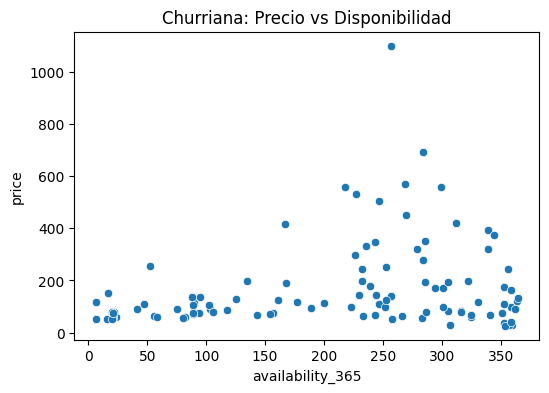

In [48]:
# Sin Novasol

df_churriana = df_2[df_2["neighbourhood"]=="Churriana"]

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_churriana,
    x="availability_365",
    y="price"
)
plt.title("Churriana: Precio vs Disponibilidad")
plt.show()

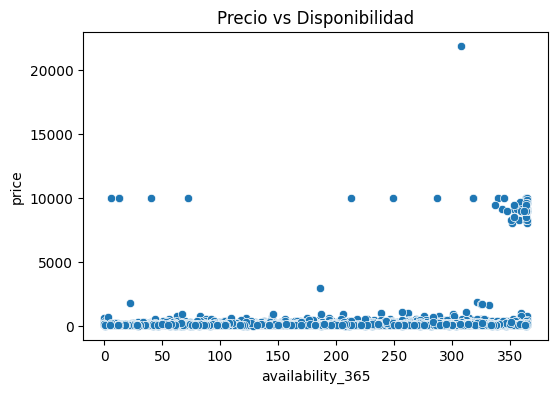

In [50]:
# Comparación de precios vs disponibilidad
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="availability_365",
    y="price"
)
plt.title("Precio vs Disponibilidad")
plt.show()

In [61]:
umbral_extremo = df["price"].quantile(0.99)

df_outliers_extremos = df[df["price"] > umbral_extremo]

df_outliers_extremos

,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
248,Beach Living in Malaga,7025320,Lucia,Este,Entire home/apt,2932.0,2,11,2025-06-24,0.80,1,186,6,VFT/MA/69459
785,2 bedroom lovely home in Málaga,154046886,Novasol,Este,Entire home/apt,9999.0,1,19,2025-09-10,0.26,1,249,4,VUT/MA/17649
1693,Vistas a la bahía de Málaga desde una villa única,336578289,Javier,Este,Entire home/apt,1066.0,4,81,2025-09-28,1.29,1,312,17,VFT/MA/39358
1782,Sleeps 24 with fabulous sea and mountain views,25632968,Claire,Este,Entire home/apt,1590.0,3,28,2025-09-15,0.65,8,332,8,A/MA/01290
1937,Teatro Romano 2,383001067,Jose,Centro,Entire home/apt,21911.0,1,163,2025-09-13,2.85,2,308,41,ESFCTU0000290200007573890000000000000000VFT/MA...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,El Pajar,686781509,Michael,Campanillas,Entire home/apt,9000.0,1,1,2025-08-04,0.52,8,364,1,ESHFTU00002900100001917200200000000000000CR/MA...
6441,Awesome home in Málaga with WiFi,153912894,Novasol,Centro,Entire home/apt,9999.0,1,1,2025-09-22,1.00,1,213,1,VUT/MA/93022
6531,Apartamentos sealmar 1,587006009,Michael,Carretera de Cadiz,Entire home/apt,9429.0,1,1,2025-09-02,1.00,6,364,1,ESFCTU0000290530011614110000000000000000VUT/MA...
6602,La Mihilla,686781509,Michael,Campanillas,Entire home/apt,9000.0,1,3,2025-09-06,1.70,8,362,3,VFT/MA/62520


In [63]:
df_outliers_extremos[["host_name"]].value_counts()


host_name
Michael      46
Novasol      12
Elena         3
Lucia         1
Javier        1
Claire        1
Jose          1
Miriam        1
Carolina      1
Belen         1
Laurent       1
Name: count, dtype: int64

In [65]:
umbral_real = df["price"].quantile(0.99)
df["es_outlier"] = df["price"] > umbral_real

df_limpio = df[df["es_outlier"] == False]

In [69]:
df_limpio.groupby("neighbourhood")["price"].mean().sort_values(ascending=False)

neighbourhood
Campanillas             204.000000
Churriana               161.298077
Palma-Palmilla          141.650407
Puerto de la Torre      139.392857
Este                    137.897168
Centro                  117.459095
Ciudad Jardin           113.134615
Carretera de Cadiz      104.079632
Cruz De Humilladero      94.245675
Teatinos-Universidad     82.217391
Bailen-Miraflores        73.589862
Name: price, dtype: float64

<Figure size 1000x500 with 0 Axes>

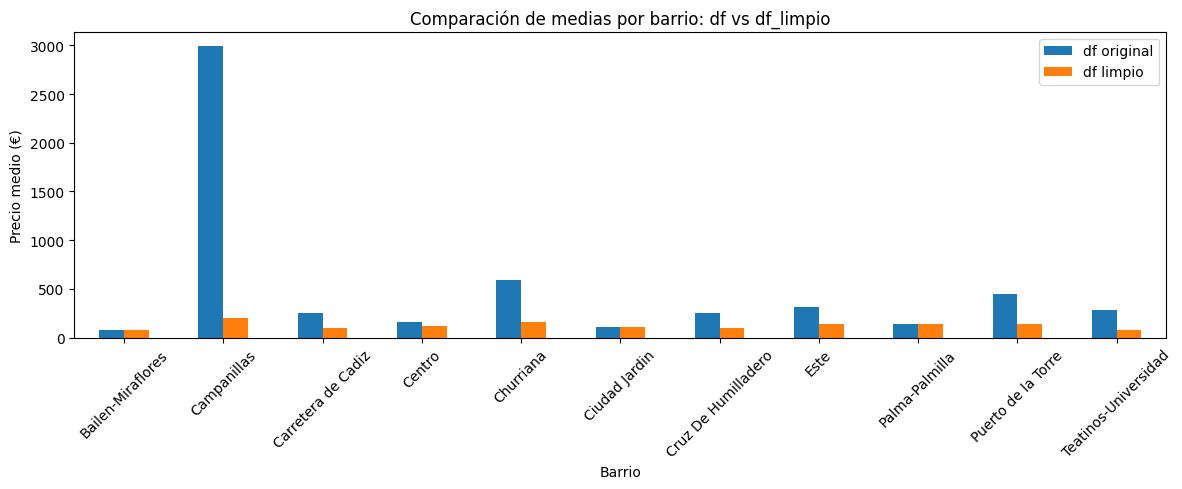

In [70]:
# Medias por barrio en df original
media_df = df.groupby("neighbourhood")["price"].mean()

# Medias por barrio en df limpio
media_df_limpio = df_limpio.groupby("neighbourhood")["price"].mean()

# Unimos ambas series en un solo DataFrame
comparacion = pd.DataFrame({
    "Media_df_original": media_df,
    "Media_df_limpio": media_df_limpio
})

# Gráfico
plt.figure(figsize=(10,5))
comparacion.plot(kind="bar", figsize=(12,5))

plt.title("Comparación de medias por barrio: df vs df_limpio")
plt.ylabel("Precio medio (€)")
plt.xlabel("Barrio")
plt.xticks(rotation=45)
plt.legend(["df original", "df limpio"])
plt.tight_layout()
plt.show()


In [ ]:
# Quitando los valores extremos la hipotesis 1 se refusta, tenemos que ver ahora cuales son los patrones que mas determinan los precios, 
# si el tipo de alojamiento, número de reseñas o disponibilidad

In [71]:
df_limpio[["price", "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month", "availability_365"]].corr()


,price,number_of_reviews,number_of_reviews_ltm,reviews_per_month,availability_365
price,1.000000,-0.103457,-0.140027,-0.150138,0.044779
number_of_reviews,-0.103457,1.000000,0.687887,0.563203,-0.097518
number_of_reviews_ltm,-0.140027,0.687887,1.000000,0.839241,-0.061797
reviews_per_month,-0.150138,0.563203,0.839241,1.000000,-0.032624
availability_365,0.044779,-0.097518,-0.061797,-0.032624,1.000000


In [ ]:
# No hay correlaciones fuertes con el precio.
# Las reseñas tienen una relación negativa débil, lo que sugiere que los alojamientos más baratos se alquilan más y acumulan más reseñas.

# La disponibilidad no influye en el precio de forma clara.

# El precio no depende directamente de reseñas ni disponibilidad.

In [72]:
df_limpio.groupby("room_type")["price"].mean().sort_values(ascending=False)


room_type
Entire home/apt    124.939474
Hotel room          57.000000
Private room        51.726402
Shared room         44.692308
Name: price, dtype: float64

In [73]:
df_limpio.groupby("neighbourhood")["price"].mean().sort_values(ascending=False)


neighbourhood
Campanillas             204.000000
Churriana               161.298077
Palma-Palmilla          141.650407
Puerto de la Torre      139.392857
Este                    137.897168
Centro                  117.459095
Ciudad Jardin           113.134615
Carretera de Cadiz      104.079632
Cruz De Humilladero      94.245675
Teatinos-Universidad     82.217391
Bailen-Miraflores        73.589862
Name: price, dtype: float64

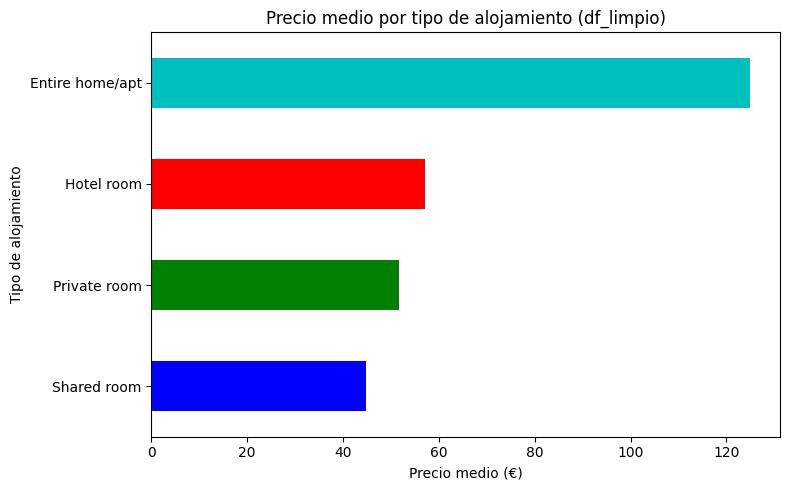

In [74]:
media_room = df_limpio.groupby("room_type")["price"].mean().sort_values()

plt.figure(figsize=(8,5))
media_room.plot(
    kind="barh",
    color=["b", "g", "r", "c"]
)

plt.title("Precio medio por tipo de alojamiento (df_limpio)")
plt.xlabel("Precio medio (€)")
plt.ylabel("Tipo de alojamiento")
plt.tight_layout()
plt.show()


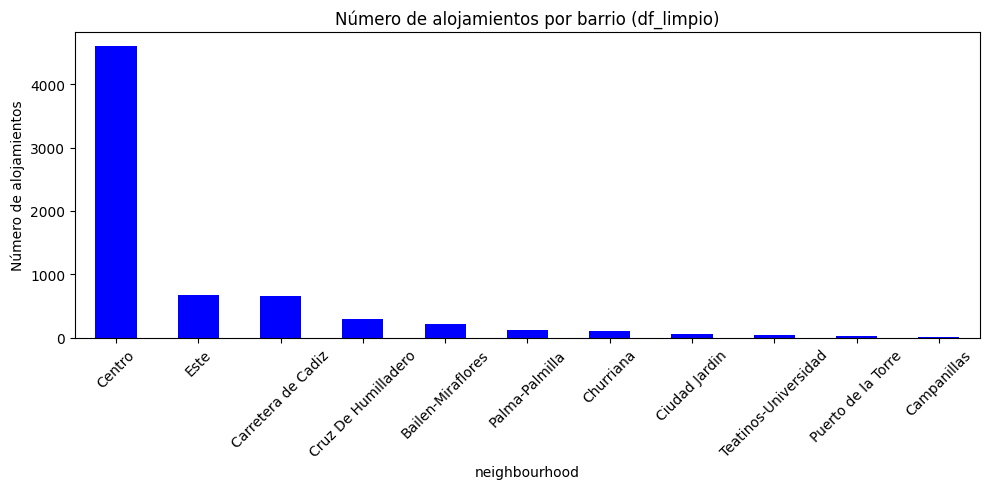

In [75]:
conteo_barrio = df_limpio["neighbourhood"].value_counts()

plt.figure(figsize=(10,5))
conteo_barrio.plot(kind="bar", color="b")

plt.title("Número de alojamientos por barrio (df_limpio)")
plt.ylabel("Número de alojamientos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


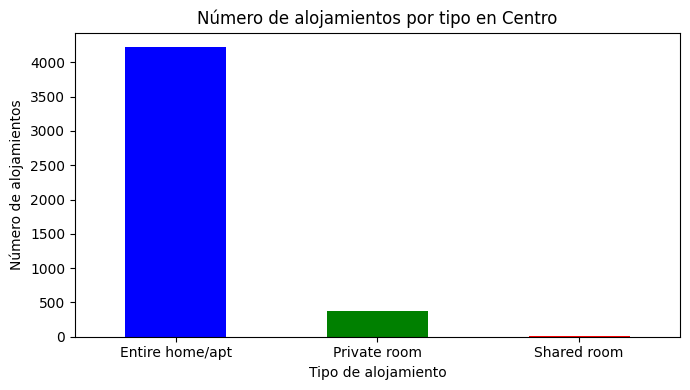

In [76]:
conteo_centro = df_limpio[df_limpio["neighbourhood"] == "Centro"]["room_type"].value_counts()

plt.figure(figsize=(7,4))
conteo_centro.plot(kind="bar", color=["b", "g", "r", "c"])

plt.title("Número de alojamientos por tipo en Centro")
plt.ylabel("Número de alojamientos")
plt.xlabel("Tipo de alojamiento")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


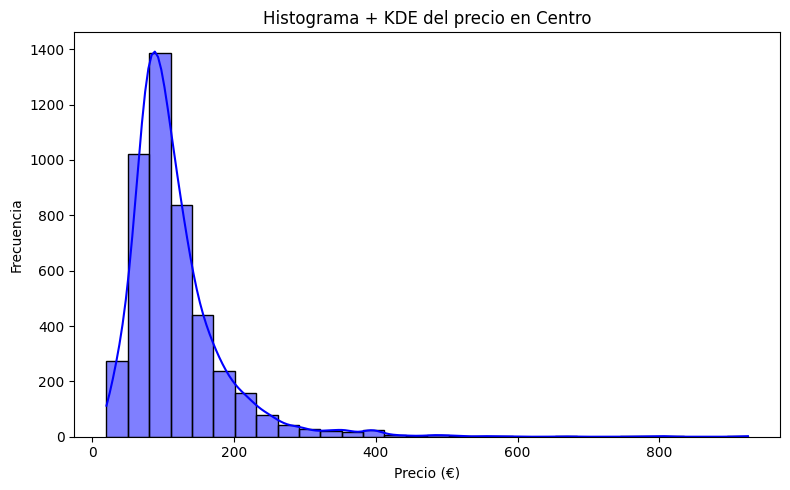

In [77]:
df_centro = df_limpio[df_limpio["neighbourhood"] == "Centro"]

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_centro,
    x="price",
    bins=30,
    kde=True,
    color="b",        # azul normal
    edgecolor="black"
)

plt.title("Histograma + KDE del precio en Centro")
plt.xlabel("Precio (€)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## 🧠 Conclusión final: por qué el Centro no es la zona más cara

Aunque el Centro es el barrio con mayor demanda turística y el que concentra el mayor número de alojamientos, los datos muestran que **no es la zona más cara**. Esto se explica por varios factores estructurales del mercado:

### 1. Exceso de oferta en el Centro
El Centro tiene más de 4.000 alojamientos, muy por encima del resto de barrios.  
Esta enorme oferta genera una fuerte competencia entre hosts, lo que tiende a **moderar los precios**.

**Alta oferta → alta competencia → precios más ajustados.**

### 2. Mezcla de tipos de alojamiento más económicos
En el Centro predominan:
- estudios pequeños,  
- habitaciones privadas,  
- alojamientos compactos.

Y el análisis demuestra que **el tipo de alojamiento es el factor que más determina el precio**.  
Como en el Centro hay muchos alojamientos pequeños, el precio medio baja.

### 3. La disponibilidad no influye en el precio
La correlación entre `availability_365` y `price` es prácticamente cero.  
Esto significa que, aunque el Centro tenga mucha rotación y demanda, **la disponibilidad no empuja los precios hacia arriba**.

### 4. Los barrios más caros tienen menos oferta y alojamientos más grandes
Barrios como Campanillas, Churriana, Este o Puerto de la Torre tienen:
- menos alojamientos,  
- viviendas más grandes,  
- demanda más específica (playa, aeropuerto, PTA, zonas residenciales).

Esto eleva el precio medio de forma natural.

### 5. El Centro es un mercado saturado y maduro
La saturación turística del Centro hace que los precios estén más estabilizados.  
Los hosts ajustan tarifas para mantener ocupación en un entorno muy competitivo.

---

### ⭐ Conclusión final
**El Centro no es el barrio más caro porque la enorme oferta y la alta competencia mantienen los precios moderados, mientras que los barrios más caros tienen menos alojamientos, viviendas más grandes y una demanda más específica que eleva el precio medio.**


In [81]:
df_outliers_extremos["price"].mean()

np.float64(8340.826086956522)

In [82]:
df_outliers_extremos["neighbourhood"].value_counts()

neighbourhood
Centro                  19
Este                    18
Carretera de Cadiz      13
Churriana                6
Campanillas              6
Cruz De Humilladero      5
Puerto de la Torre       1
Teatinos-Universidad     1
Name: count, dtype: int64

In [83]:
df_outliers_extremos["room_type"].value_counts()

room_type
Entire home/apt    69
Name: count, dtype: int64

In [84]:
df_outliers_extremos["host_name"].value_counts()

host_name
Michael     46
Novasol     12
Elena        3
Lucia        1
Javier       1
Claire       1
Jose         1
Miriam       1
Carolina     1
Belen        1
Laurent      1
Name: count, dtype: int64

In [87]:
df_outliers_extremos.groupby("host_name")["price"].mean().sort_values(ascending=False)

host_name
Jose        21911.000000
Novasol     10000.250000
Michael      9084.739130
Lucia        2932.000000
Elena        1755.666667
Laurent      1750.000000
Claire       1590.000000
Belen        1100.000000
Javier       1066.000000
Carolina     1000.000000
Miriam       1000.000000
Name: price, dtype: float64